<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/Machine-Learning/Logistic_Regression_Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report


In [2]:
import kagglehub
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.


In [3]:
raw_df=pd.read_csv(path+'/weatherAUS.csv')
raw_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [5]:
raw_df.dropna(subset=['RainToday','RainTomorrow'],inplace=True)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  object 
 1   Location       140787 non-null  object 
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  object 
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  object 
 10  WindDir3pm     137117 non-null  object 
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   fl

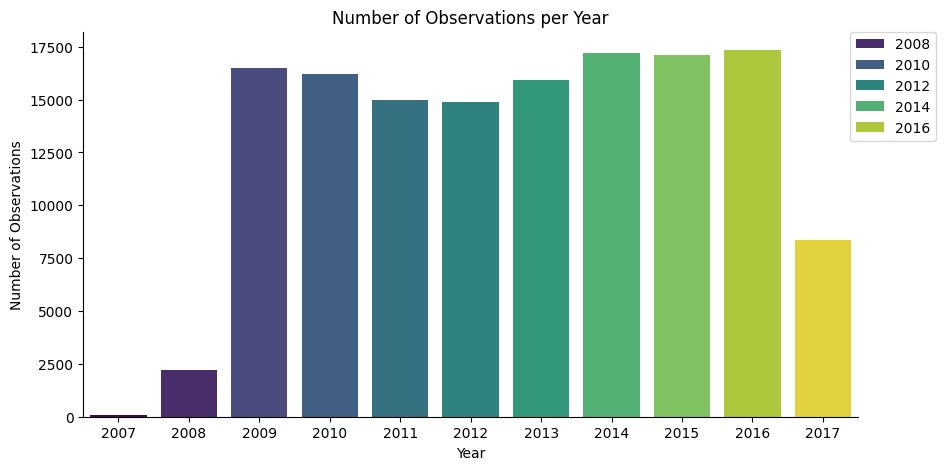

In [6]:
year=pd.to_datetime(raw_df['Date']).dt.year

plt.figure(figsize=(10,5))
sns.countplot(x=year,palette='viridis',hue=year)
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Observations')

plt.legend(bbox_to_anchor=(1.1,1),loc='upper right',borderaxespad=0)

sns.despine()
plt.show()


In [7]:
from pandas.core.arrays import categorical
numeric_cols=raw_df.select_dtypes(include=['float64']).columns.tolist()
categorical_cols=raw_df.select_dtypes(include=['object']).columns.tolist()[1:-1]
print(numeric_cols)
print(categorical_cols)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


In [8]:
# for filling nan values
imputer=SimpleImputer(strategy='median')
raw_df[numeric_cols]=imputer.fit_transform(raw_df[numeric_cols])

In [9]:
raw_df.isna().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,9163
WindGustSpeed,0
WindDir9am,9660


In [10]:
raw_df[categorical_cols].nunique()

,0
Location,49
WindGustDir,16
WindDir9am,16
WindDir3pm,16
RainToday,2


In [11]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoded_df=(pd.DataFrame(encoder.fit_transform(raw_df[categorical_cols]),columns=encoder.get_feature_names_out(categorical_cols)))

encoded_cols=encoded_df.columns.tolist()

In [12]:
encoded_df.head()

,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
raw_df=pd.concat([raw_df,encoded_df],axis=1)

In [14]:
raw_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,W,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,NNW,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,W,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,SE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,ENE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
raw_df.dropna(inplace=True)

In [16]:
raw_df['year']=pd.to_datetime(raw_df['Date']).dt.year

In [17]:
## Spliting data for training and test

input_col=(numeric_cols+encoded_cols)

input=raw_df[input_col]
target=raw_df['RainTomorrow']

input_train=input[raw_df['year']<2015]
input_test=input[raw_df['year']>=2015]

target_train=target[raw_df['year']<2015]
target_test=target[raw_df['year']>=2015]

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data to prevent data leakage, then transform both!
input_train_scaled = scaler.fit_transform(input_train)
input_test_scaled = scaler.fit_transform(input_test)

In [19]:
model=LogisticRegression()
model.fit(input_train_scaled,target_train)

pred=model.predict(input_test_scaled)

print(f"Model Raw accuracy {accuracy_score(target_test,pred)*100}")

Model Raw accuracy 84.29754378112236


In [20]:
array=np.array([['True Negative(TN)','False Positive(Type 1 error)'],['False Negative(Type 2 error)','True Positive(TP)']])
print(array)
cm=confusion_matrix(target_test,pred,normalize='true')
print('\n',cm)

[['True Negative(TN)' 'False Positive(Type 1 error)']
 ['False Negative(Type 2 error)' 'True Positive(TP)']]

 [[0.94188975 0.05811025]
 [0.50264018 0.49735982]]


### Balanced Model to Decrease the False Negative

In [21]:
model_balanced=LogisticRegression(class_weight='balanced')
model_balanced.fit(input_train_scaled,target_train)

pred_balanced=model_balanced.predict(input_test_scaled)

print(f"Model balanced accuracy {accuracy_score(target_test,pred_balanced)*100}")
print(f'\nClassification Report\n{classification_report(target_test,pred_balanced)}')
print(f'\nConfusion Matrix\n{confusion_matrix(target_test,pred_balanced,normalize="true")}')

Model balanced accuracy 79.2396352039389

Classification Report
              precision    recall  f1-score   support

          No       0.92      0.80      0.86     27792
         Yes       0.52      0.75      0.62      7954

    accuracy                           0.79     35746
   macro avg       0.72      0.78      0.74     35746
weighted avg       0.83      0.79      0.80     35746


Confusion Matrix
[[0.80368451 0.19631549]
 [0.24704551 0.75295449]]


In [22]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.unique(target_train), y=target_train)
print(weights)

[0.64437608 2.23158879]


### Custom Weight To find the best Spot

In [23]:
custom_weight={'No':0.95,'Yes':1.8}
model_custom=LogisticRegression(class_weight=custom_weight)
model_custom.fit(input_train_scaled,target_train)

pred_custom=model_custom.predict(input_test_scaled)

print(f"Model custom accuracy {accuracy_score(target_test,pred_custom)*100}")
print(f'\nClassification Report\n{classification_report(target_test,pred_custom)}')
print(f'\nConfusion Matrix\n{confusion_matrix(target_test,pred_custom,normalize='true')}')

Model custom accuracy 83.08342192133385

Classification Report
              precision    recall  f1-score   support

          No       0.89      0.89      0.89     27792
         Yes       0.62      0.63      0.62      7954

    accuracy                           0.83     35746
   macro avg       0.76      0.76      0.76     35746
weighted avg       0.83      0.83      0.83     35746


Confusion Matrix
[[0.88748561 0.11251439]
 [0.36711089 0.63288911]]


## Random Forest Classifier

In [24]:
from sklearn.ensemble import RandomForestClassifier

model_rf=RandomForestClassifier()
model_rf.fit(input_train_scaled,target_train)

pred_rf=model_rf.predict(input_test_scaled)

print(f"Model Random Forest accuracy {accuracy_score(target_test,pred_rf)*100}")
print(f'\nClassification Report\n{classification_report(target_test,pred_rf)}')
print(f'\nConfusion Matrix\n{confusion_matrix(target_test,pred_rf,normalize="true")}')

Model Random Forest accuracy 84.94656744810608

Classification Report
              precision    recall  f1-score   support

          No       0.86      0.96      0.91     27792
         Yes       0.76      0.48      0.58      7954

    accuracy                           0.85     35746
   macro avg       0.81      0.72      0.75     35746
weighted avg       0.84      0.85      0.84     35746


Confusion Matrix
[[0.95649827 0.04350173]
 [0.52451597 0.47548403]]


In [25]:
model_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

### Hyper Tunning the Model

In [26]:
model_H_rf=RandomForestClassifier(n_jobs=-1,
                                  random_state=42,
                                  n_estimators=500,
                                  max_features=40,
                                  max_depth=20,
                                  class_weight={'No':0.85,'Yes':1.85},
                                  bootstrap=True,
                                  min_samples_leaf=20,
                                  min_samples_split=20,
                                  max_samples=0.9

                                  )
model_H_rf.fit(input_train_scaled,target_train)

pred_H_rf=model_H_rf.predict(input_test_scaled)

print(f"Model Random Forest accuracy {accuracy_score(target_test,pred_H_rf)*100}")
print(f'\nClassification Report\n{classification_report(target_test,pred_H_rf)}')
print(f'\nConfusion Matrix\n{confusion_matrix(target_test,pred_H_rf,normalize="true")}')


Model Random Forest accuracy 83.95624685279472

Classification Report
              precision    recall  f1-score   support

          No       0.90      0.90      0.90     27792
         Yes       0.64      0.64      0.64      7954

    accuracy                           0.84     35746
   macro avg       0.77      0.77      0.77     35746
weighted avg       0.84      0.84      0.84     35746


Confusion Matrix
[[0.89712867 0.10287133]
 [0.36157908 0.63842092]]


### Important Features

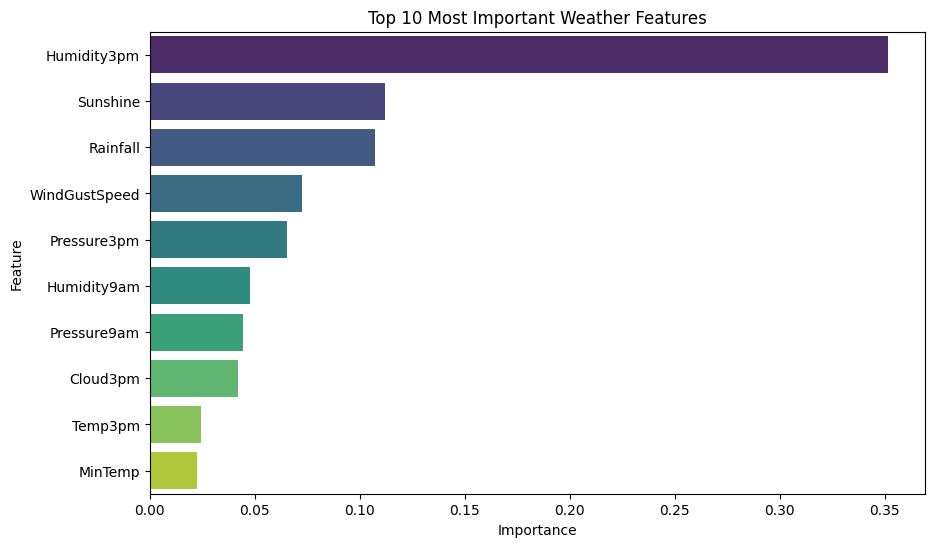

In [27]:
importances = model_H_rf.feature_importances_
feature_names = numeric_cols + list(encoded_cols)

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis',hue='Feature')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Weather Features')
plt.show()

### Removing Non Important Feature

In [28]:
from sklearn.feature_selection import SelectFromModel

# This will automatically pick only the features that actually matter
selector = SelectFromModel(model_H_rf, prefit=True, threshold=0.03)

# Transform your training and test inputs instantly without changing the original DataFrames
input_train_selected = selector.transform(input_train_scaled)
input_test_selected = selector.transform(input_test_scaled)

In [29]:
model_S_rf=RandomForestClassifier(n_jobs=-1,
                                  random_state=42,
                                  n_estimators=500,
                                  max_features=40,
                                  max_depth=20,
                                  class_weight={'No':0.85,'Yes':1.85},
                                  bootstrap=True,
                                  min_samples_leaf=20,
                                  min_samples_split=20,
                                  max_samples=0.9

                                  )
model_S_rf.fit(input_train_selected,target_train)

pred_S_rf=model_S_rf.predict(input_test_selected)

print(f"Model Random Forest accuracy {accuracy_score(target_test,pred_S_rf)*100}")
print(f'\nClassification Report\n{classification_report(target_test,pred_S_rf)}')
print(f'\nConfusion Matrix\n{confusion_matrix(target_test,pred_S_rf,normalize="true")}')

Model Random Forest accuracy 83.2680579645275

Classification Report
              precision    recall  f1-score   support

          No       0.90      0.89      0.89     27792
         Yes       0.62      0.64      0.63      7954

    accuracy                           0.83     35746
   macro avg       0.76      0.76      0.76     35746
weighted avg       0.83      0.83      0.83     35746


Confusion Matrix
[[0.888673   0.111327  ]
 [0.36296203 0.63703797]]


###  Key Findings & Model Comparison

* **Model Performance:** The baseline Logistic Regression model achieved 83.1% accuracy with a custom-weighted recall of 63%. Upgrading to a highly-tuned Random Forest Classifier (`n_estimators=500`, `max_depth=20`) yielded a minor accuracy shift (~83.9% accuracy, 63.8% recall).
* **The Data Ceiling** The fact that a massive tree ensemble barely outperformed a simple linear model indicates we have hit a "data ceiling"—the current features have reached their maximum predictive power.
* **Conclusion:** Following Occam's Razor, **Logistic Regression is the superior model for production on this dataset.** It delivers virtually identical predictive power while running in seconds, compared to the heavy computational overhead and multi-minute training time of the Random Forest.